In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

In [2]:
Data = 'data/data.csv'

df = pd.read_csv(Data, sep=';')


### Feature selection

In [3]:
features = df.drop(columns=['Target'])
target = df['Target']

discrete_features = ['Marital Status', 'Application mode', 'Application order', 'Course',
                     'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
                     "Mother's qualification", "Father's qualification", "Mother's occupation",
                     "Father's occupation", "Displaced", 'Educational special needs', 'Debtor',
                     'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

is_dicrete = [feature in discrete_features for feature in features]


MI_scores = mutual_info_classif(features, target, discrete_features=is_dicrete, random_state=42)
MI_results = pd.Series(MI_scores, name="MI Scores", index=features.columns)
MI_results = MI_results.sort_values(ascending=False)

MI_results

Curricular units 2nd sem (approved)               0.313784
Curricular units 1st sem (approved)               0.261520
Curricular units 2nd sem (grade)                  0.235074
Curricular units 1st sem (grade)                  0.194813
Curricular units 2nd sem (evaluations)            0.098819
Tuition fees up to date                           0.091828
Curricular units 1st sem (evaluations)            0.087872
Course                                            0.066468
Application mode                                  0.052221
Scholarship holder                                0.049156
Curricular units 1st sem (enrolled)               0.048512
Curricular units 2nd sem (enrolled)               0.046484
Previous qualification (grade)                    0.046057
Age at enrollment                                 0.043472
Admission grade                                   0.034483
Mother's occupation                               0.034022
Father's occupation                               0.0308

/tmp/ipykernel_9260/3966950961.py:9: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/bbo/Documents/Code/projects/dropout-risk-factor-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


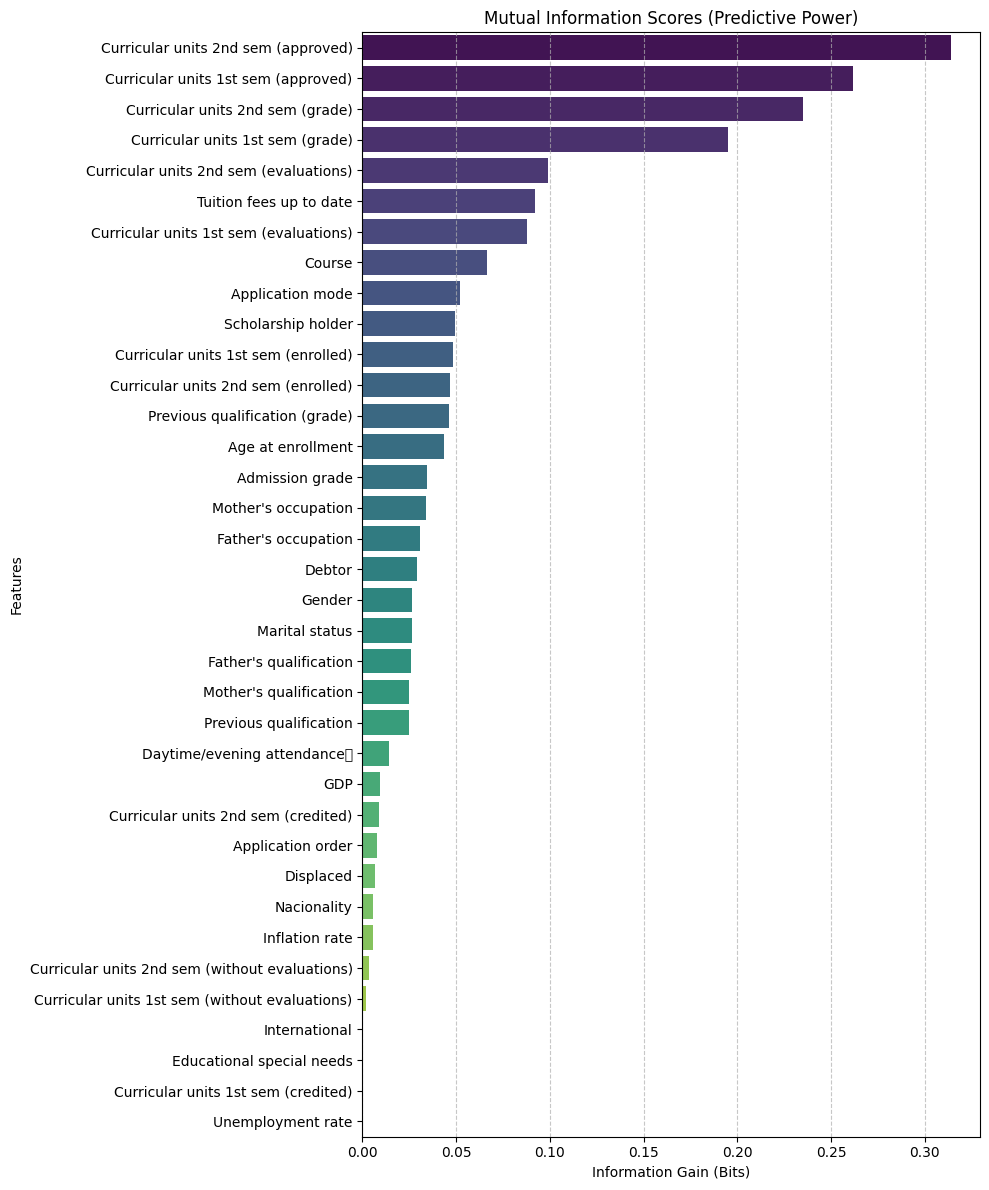

In [4]:
plt.figure(figsize=(10, 12))
sns.barplot(x=MI_results.values, y=MI_results.index, hue=MI_results.index, palette='viridis', legend=False)

plt.title("Mutual Information Scores (Predictive Power)")
plt.xlabel("Information Gain (Bits)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [26]:
features_to_drop = MI_results[MI_results < 0.02].index.tolist()

Data_X_some_features_dropped = df.drop(columns=features_to_drop)

Data_X_some_features_dropped.to_csv('data/data(Some features dropped).csv', index=False)

test = Data_X_some_features_dropped

In [17]:
Data_X_some_features_dropped['Grade_Trend'] = Data_X_some_features_dropped['Curricular units 2nd sem (grade)'] - Data_X_some_features_dropped['Curricular units 1st sem (grade)']
Data_X_some_features_dropped['Approval_Rate_2nd'] = Data_X_some_features_dropped['Curricular units 2nd sem (approved)'] / Data_X_some_features_dropped['Curricular units 2nd sem (enrolled)'].replace(0, 1)
Data_X_some_features_dropped['Financial_Risk_Score'] = Data_X_some_features_dropped['Debtor'] + (1 - Data_X_some_features_dropped['Tuition fees up to date']) - Data_X_some_features_dropped['Scholarship holder']

In [18]:
Data_X_some_features_dropped_features_added = Data_X_some_features_dropped
Data_X_some_features_dropped_features_added.to_csv('data/data(Some features added).csv', index=False)

In [31]:
binary_data = Data_X_some_features_dropped_features_added[Data_X_some_features_dropped_features_added['Target'] != 'Enrolled']
binary_data.to_csv('data/Binary_data.csv', index=False)